/var/folders/g2/p06t4qmx0ys102r1knn051hw0000gn/T/ipykernel_49908/39667498.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contribution (%)', y=loadings.index, data=loadings, palette='viridis')


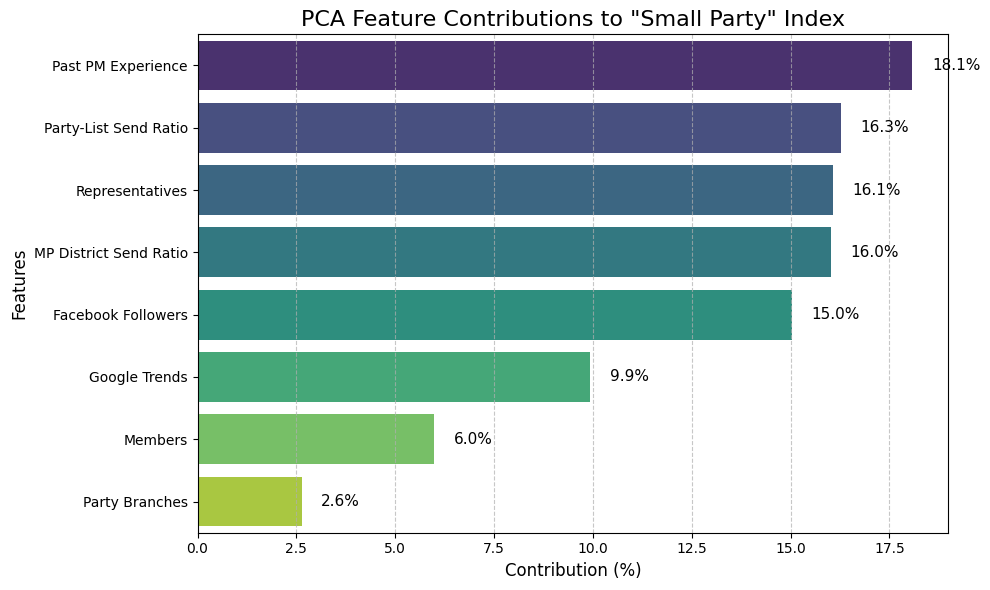

,PCA_Weight (PC1),Contribution (%)
Past PM Experience,0.471014,18.080174
Party-List Send Ratio,0.423763,16.266415
Representatives,0.418662,16.070623
MP District Send Ratio,0.417372,16.021123
Facebook Followers,0.391556,15.030150
Google Trends,0.258509,9.923045
Members,0.155741,5.978230
Party Branches,0.068521,2.630237


,Party,sent_pm_district_ratio,sent_pm_partylist_ratio,social_media_followers_scaled,branch_scaled,representative_scaled,member_scaled,trends_scaled,past_pm,PCA_Index,small
0,กรีน,0.005000,0.120000,0.652096,0.233333,0.041096,0.493140,0.006485,0.000000,0.137355,1.000000
2,ก้าวอิสระ,0.015000,0.150000,0.668957,0.000000,0.000000,0.000000,0.000000,0.000000,0.100323,1.000000
3,ครูไทยเพื่อประชาชน,0.002500,0.220000,0.000000,0.200000,0.041096,0.598036,0.000000,0.000000,0.052685,1.000000
4,คลองไทย,0.005000,0.160000,0.520813,0.133333,0.000000,0.696621,0.000000,0.000000,0.125388,1.000000
5,ความหวังใหม่,0.002500,0.080000,0.000000,0.166667,0.027397,0.499099,0.003891,0.000000,0.018355,1.000000


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv('data/ins-1/small_party.csv', index_col=0)

# Select features used for PCA based on the actual pipeline
features = [
    'sent_pm_district_ratio',
    'sent_pm_partylist_ratio',
    'social_media_followers_scaled', 
    'branch_scaled', 
    'representative_scaled', 
    'member_scaled', 
    'trends_scaled',
    'past_pm'
]

# Display names for the chart
feature_display_names = [
    'MP District Send Ratio',
    'Party-List Send Ratio',
    'Facebook Followers', 
    'Party Branches', 
    'Representatives', 
    'Members', 
    'Google Trends',
    'Past PM Experience'
]

X = df[features].fillna(0)

# Run PCA
pca = PCA(n_components=1)
pca.fit(X)

# Create PCA feature weights (loadings) table
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PCA_Weight (PC1)'], 
    index=feature_display_names
)
loadings['Contribution (%)'] = (loadings['PCA_Weight (PC1)'].abs() / loadings['PCA_Weight (PC1)'].abs().sum()) * 100
loadings = loadings.sort_values(by='Contribution (%)', ascending=False)

# Plotting Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Contribution (%)', y=loadings.index, data=loadings, palette='viridis')
plt.title('PCA Feature Contributions to "Small Party" Index', fontsize=16)
plt.xlabel('Contribution (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
for index, value in enumerate(loadings['Contribution (%)']):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('pca_feature_weights.png', dpi=300)
plt.show()

# Display styled table
display(loadings.style.background_gradient(cmap='Blues'))

# Show a sample of how the PCA Index looks like for top 5 small parties
sample_df = df[['Party'] + features + ['PCA_Index', 'small']].copy()
display(sample_df[sample_df['small'] == 1.0].head(5).style.background_gradient(cmap='Reds', subset=['PCA_Index']))
